# Artificial Neural Network Modeling

Train and evaluate a Multi-Layer Perceptron (MLP) model to predict nucleotide changes in DENV genome regions (E, 5′UTR, 3′UTR) using environmental data (temperature, CO₂), as part of a comparative study for climate-aware viral evolution forecasting.

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)

import joblib

2025-07-23 23:35:13.934245: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load processed data

In [2]:
df = pd.read_csv('../data/processed_genomic_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (359, 2017)


,Avg_Temp_C,CO2_Emission_Mt,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,...,p_2006,p_2007,p_2008,p_2009,p_2010,p_2011,p_2012,p_2013,p_2014,p_2015
0,26.16,2489.9,4,4,3,1,4,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
3,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,26.16,2489.9,4,3,2,3,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


### Define features and targets (X & y)

In [3]:
feature_cols = df.columns[:2]        
target_cols = df.columns[2:]         

X = df[feature_cols]
y = df[target_cols]

print("Shape of X (features):", X.shape)
print("Shape of y (targets):", y.shape)

Shape of X (features): (359, 2)
Shape of y (targets): (359, 2015)


### Train-Test Split

In [6]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 251
Test set size: 108


### ANN Model Architecture and Training

We implement a feedforward multi-layer perceptron with a large multi-output softmax head, enabling simultaneous multi-class prediction across all 2015 nucleotide positions from environmental variables.

#### Define the model

In [7]:
model = Sequential([
    Input(shape=(2,)),                          # 2 environmental variables
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2015 * 5, activation='softmax'),      # Output: 2015 positions × 5 classes
    Reshape((2015, 5))                          # Shape: (n_samples, 2015, 5)
])

#### Compile the model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # Because y is integer encoded (not one-hot)
    metrics=['accuracy']
)

#### Print the summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10075)          │     1,299,675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2015, 5)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,316,571 (5.02 MB)

 Trainable params: 1,316,571 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

#### Early stopping callback

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Fit the model

In [11]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.1337 - loss: 1.6434 - val_accuracy: 0.0630 - val_loss: 1.6442
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0675 - loss: 1.6178 - val_accuracy: 0.0553 - val_loss: 1.6209
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0527 - loss: 1.6135 - val_accuracy: 0.0549 - val_loss: 1.6207
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0503 - loss: 1.6128 - val_accuracy: 0.0536 - val_loss: 1.6102
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0499 - loss: 1.6092 - val_accuracy: 0.0529 - val_loss: 1.6099
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0531 - loss: 1.6031 - val_accuracy: 0.0566 - val_loss: 1.6227
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0554 - loss: 1.6067 - val_accuracy: 0.0540 - val_loss: 1.6113
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0470 - loss: 1.6095 - val_accuracy: 0.0531 - val_loss: 1.6097


**Model Hyperparameter Choices:**

- *Hidden Layers = 2, Units per Layer = 128:*

    Two dense hidden layers with 128 neurons each provide enough capacity to model potential nonlinear relationships between environmental variables and nucleotide positions, while minimizing the risk of overfitting on the small input dimension (2 features). This architecture is widely used as a baseline in tabular data modeling, balancing simplicity and expressive power.

- *Activation Function = ReLU:*

    Rectified Linear Unit (ReLU) is chosen for the hidden layers due to its efficiency and ability to mitigate the vanishing gradient problem, making training faster and more stable for moderately deep networks.

- *Dropout Rate = 0.3:*

    A dropout rate of 30% is applied after each hidden layer to reduce overfitting by randomly disabling a subset of neurons during training, which is especially important for small datasets and prevents the network from relying too heavily on any one pattern.

- *Output Layer = Dense(2015×5) with Softmax, Reshaped to (2015, 5):*

    The final dense layer outputs a softmax probability distribution for each of the 2015 nucleotide positions, enabling simultaneous multi-class classification. The output is reshaped to allow interpretation as a set of 2015 independent categorical predictions, directly analogous to the multi-output approach used for Random Forests.

- *Loss Function = sparse_categorical_crossentropy:*

    This loss function is chosen for its compatibility with integer-encoded categorical targets, which avoids the memory and computation overhead of one-hot encoding, and aligns with standard practice for multi-class classification in Keras.

- *Optimizer = Adam:*

    Adam optimizer is selected for its efficiency and robustness in training neural networks with adaptive learning rates, requiring minimal manual tuning and performing well across a range of tasks.

- *Batch Size = 32:*

    A mini-batch size of 32 is used to strike a balance between convergence speed and noise in gradient estimates, a value commonly recommended in neural network training.

- *Epochs = 50 with Early Stopping (patience=5):*

    The maximum number of epochs is set to 50, but early stopping is employed to halt training if validation loss does not improve for 5 consecutive epochs. This prevents overfitting and ensures that the best model (by validation loss) is retained.

*As with the Random Forest model, comprehensive hyperparameter tuning (e.g., grid search or Bayesian optimization) is reserved for future work to maintain computational simplicity and focus on core research objectives.*

#### Learning curve plot

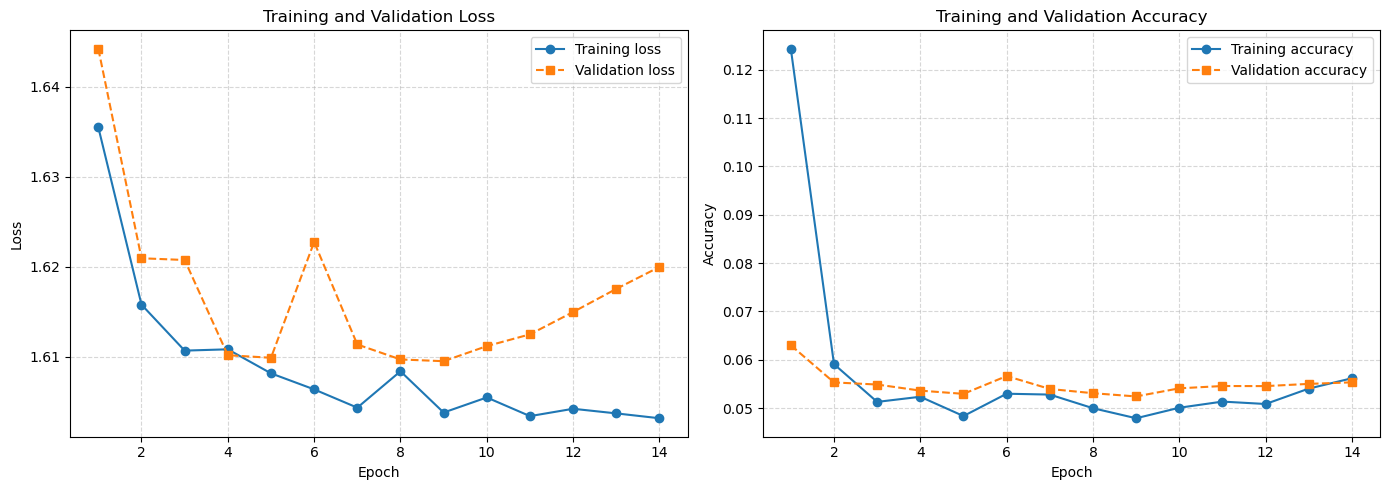

In [30]:
# Extract the history data
history_dict = history.history

# Get loss and accuracy
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'o-', label='Training loss')
plt.plot(epochs, val_loss, 's--', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'o-', label='Training accuracy')
plt.plot(epochs, val_accuracy, 's--', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Analysis of Training and Validation Curves for ANN Model

The above plots illustrate the progression of training and validation loss (left) and accuracy (right) for the Artificial Neural Network (ANN) model over successive epochs. Each point represents the model's performance on either the training set or a held-out validation set after each epoch of learning.

#### Key Insights:

- **Model convergence and stability:**
    Both training and validation loss decrease sharply in the initial epochs and then plateau, indicating rapid convergence to a local minimum. The loss curves remain closely aligned throughout training, with no evidence of severe divergence or overfitting.

- **Validation performance and generalization:**
    Validation loss fluctuates slightly but does not show a clear, sustained downward trend, and both validation loss and accuracy remain nearly flat after the early epochs. This plateauing, coupled with low accuracy values, suggests that the model is unable to extract strong predictive signals from the input features (environmental variables).

- **Accuracy trends:**
    Training and validation accuracy both remain low—consistently below 0.13—across all epochs. This indicates that the ANN is essentially making near-random predictions for the multi-class nucleotide classification task.

- **Overfitting check:**
    There is no pronounced gap between training and validation curves, suggesting the model is not overfitting. Instead, the primary limitation appears to be underfitting: the ANN lacks sufficient information or complexity in the features to capture the underlying relationship between environment and nucleotide state.

### Model Evaluation

#### Predict on test set

In [12]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Take the argmax to get predicted class for each position
y_pred = y_pred_prob.argmax(axis=-1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


#### Overall accuracy

In [13]:
overall_accuracy = (y_pred == y_test.values).mean()
print(f"Overall nucleotide-level accuracy: {overall_accuracy:.3f}")

Overall nucleotide-level accuracy: 0.055


#### Per-position accuracy

In [14]:
per_position_accuracy = (y_pred == y_test.values).mean(axis=0)

per_position_df = pd.DataFrame({
    'position': target_cols,         
    'accuracy': per_position_accuracy
})

print(per_position_df.head())

  position  accuracy
0      p_1  0.009259
1      p_2  0.037037
2      p_3  0.037037
3      p_4  0.018519
4      p_5  0.037037


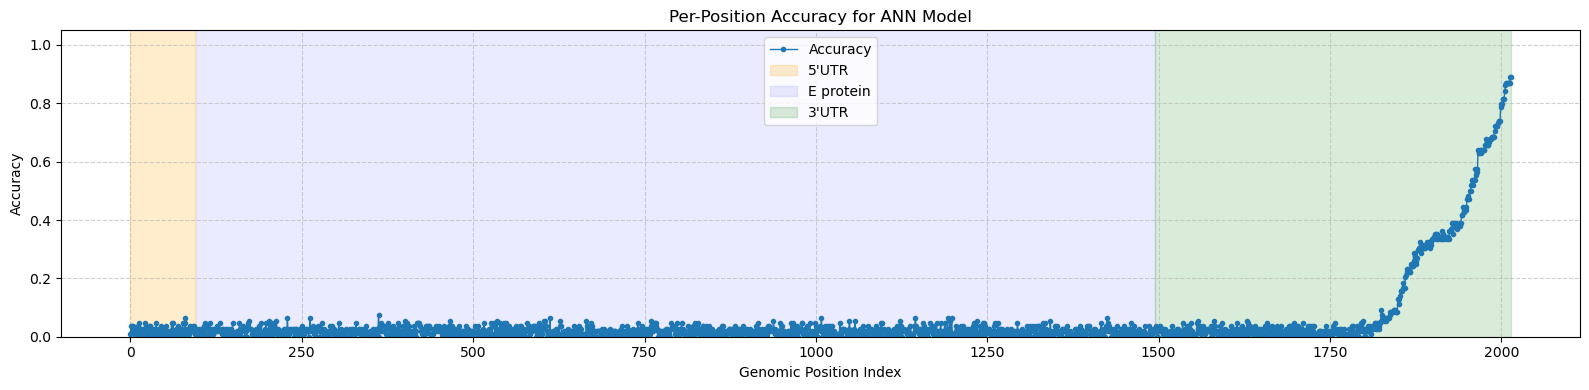

In [24]:
# Plot per-position accuracy with region labels (E, 5′UTR, 3′UTR)
utr5_start, utr5_end = 0, 94
e_start, e_end = 95, 1494
utr3_start, utr3_end = 1495, 2014

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), per_position_accuracy, marker='.', linestyle='-', linewidth=1, label='Accuracy')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per-Position Accuracy for ANN Model') 
plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy for ANN Model

The above plot presents the per-position nucleotide prediction accuracy of the Artificial Neural Network (ANN) model across all positions within the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. Each data point represents the proportion of correct nucleotide predictions at a specific genomic position on the test set, while the colored background regions demarcate the three biologically distinct segments: 5′UTR (orange), E protein (blue), and 3′UTR (green).

#### Key Insights:

- **Overall accuracy profile:**  
  The ANN model exhibits uniformly low accuracy across the vast majority of nucleotide positions, with values clustering close to zero. This trend persists throughout the 5′UTR and E protein regions, as well as the initial portion of the 3′UTR.

- **Distinct pattern in 3′UTR:**  
  A dramatic increase in prediction accuracy is observed towards the distal end of the 3′UTR region, with per-position accuracy rising sharply and exceeding 0.8 for the final positions. This pattern mirrors a similar trend seen in other models and likely corresponds to regions with extensive sequence padding or highly conserved sites, where prediction is trivially easy.

- **Limited predictive signal:**  
  The low per-position accuracy in most regions suggests that the ANN, when trained solely on environmental variables, is unable to capture the complex, position-specific determinants of nucleotide identity. This reinforces the challenge of using generic environmental inputs for high-resolution genomic forecasting.

- **Biological and technical interpretation:**  
  The pattern of high accuracy at the sequence tail is a technical artifact arising from length normalization (padding with 'N'), rather than genuine model learning. In contrast, the uniformly low accuracy across the core functional regions (5′UTR and E protein) indicates limited biological signal captured by the ANN from climate data alone.

In [16]:
# Save per-position accuracy
per_position_df.to_csv('../results/ann_per_position_accuracy.csv', index=False)

#### Calculate per-position Classification Report and Confusion Matrix

In [18]:
report_list = []
conf_matrix_list = []

for idx, col in enumerate(target_cols):
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]
    report = classification_report(y_true_col, y_pred_col, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_col, y_pred_col)

    # Flattened classification report (main averages and support)
    row = {
        'position': col,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'support': report['weighted avg']['support']
    }
    # Per-class F1, precision, recall, support
    for base in ['0', '1', '2', '3', '4']:  # Class labels as string
        if base in report:
            row[f'f1_{base}'] = report[base]['f1-score']
            row[f'precision_{base}'] = report[base]['precision']
            row[f'recall_{base}'] = report[base]['recall']
            row[f'support_{base}'] = report[base]['support']
    report_list.append(row)

    # Confusion matrix as a list
    conf_matrix_list.append({
        'position': col,
        'confusion_matrix': cm.tolist()
    })

# Convert to DataFrames
report_df = pd.DataFrame(report_list)
conf_matrix_df = pd.DataFrame(conf_matrix_list)

In [19]:
report_df.head()

,position,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,support,f1_0,precision_0,...,recall_2,support_2,f1_3,precision_3,recall_3,support_3,f1_4,precision_4,recall_4,support_4
0,p_1,0.012121,0.022222,0.008333,0.013468,0.024691,0.009259,108.0,0.0,0.0,...,0.0,18.0,0.060606,0.111111,0.041667,24.0,0.00,0.0,0.000000,5.0
1,p_2,0.034043,0.088889,0.021053,0.059890,0.156379,0.037037,108.0,0.0,0.0,...,0.0,21.0,0.000000,0.000000,0.000000,28.0,0.00,0.0,0.000000,21.0
2,p_3,0.032000,0.100000,0.019048,0.062222,0.194444,0.037037,108.0,0.0,0.0,...,0.0,34.0,0.000000,0.000000,0.000000,22.0,0.16,0.5,0.095238,42.0
3,p_4,0.034783,0.050000,0.026667,0.024155,0.034722,0.018519,108.0,0.0,0.0,...,0.0,61.0,0.000000,0.000000,0.000000,14.0,0.00,0.0,0.000000,18.0
4,p_5,0.022535,0.100000,0.012698,0.065728,0.291667,0.037037,108.0,0.0,0.0,...,0.0,19.0,0.112676,0.500000,0.063492,63.0,0.00,0.0,0.000000,11.0


In [20]:
conf_matrix_df.head()

,position,confusion_matrix
0,p_1,"[[0, 0, 0, 0, 0], [56, 0, 0, 5, 0], [15, 0, 0,..."
1,p_2,"[[0, 0, 0, 0, 0], [34, 4, 0, 0, 0], [18, 3, 0,..."
2,p_3,"[[0, 0, 0, 0, 0], [10, 0, 0, 0, 0], [31, 0, 0,..."
3,p_4,"[[0, 0, 0, 0, 0], [13, 2, 0, 0, 0], [58, 3, 0,..."
4,p_5,"[[0, 0, 0, 0, 0], [13, 0, 0, 2, 0], [17, 0, 0,..."


#### Plot Macro F1 from classification report

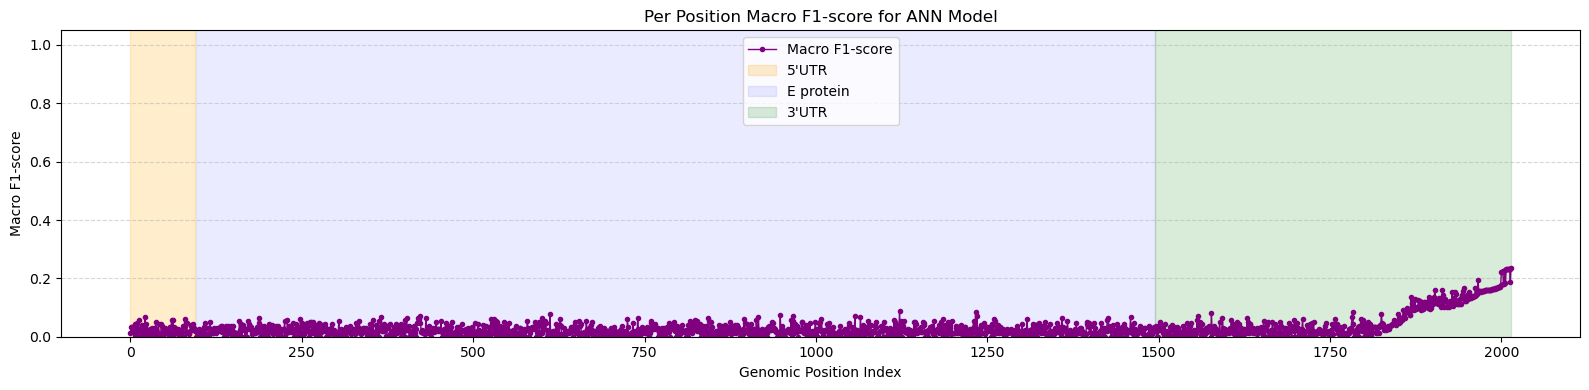

In [21]:
# Extract macro F1 for all positions
positions = report_df['position']
macro_f1 = report_df['macro_f1']

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), macro_f1, marker='.', linestyle='-', linewidth=1, color='purple', label='Macro F1-score')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per Position Macro F1-score for ANN Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1-score for ANN Model

The above plot depicts the macro-averaged F1-score at each nucleotide position for the Artificial Neural Network (ANN) model, evaluated across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. The macro F1-score provides a balanced measure of predictive performance for all nucleotide classes (A, T, G, C, N) at each position, regardless of class imbalance. Colored background regions highlight the three major genome segments: 5′UTR (orange), E protein (blue), and 3′UTR (green).

#### Key Insights:

- **Uniformly low F1 performance:**  
  The macro F1-score remains extremely low (near zero) across almost all positions within the 5′UTR and E protein regions, as well as the majority of the 3′UTR. This indicates that the ANN model, when trained solely on environmental variables, is unable to meaningfully distinguish among the nucleotide classes at most positions.

- **Rise at sequence tail:**  
  There is a noticeable increase in macro F1-score towards the terminal end of the 3′UTR, with some positions exceeding 0.2. This likely corresponds to highly conserved or padded positions, where the prediction task becomes trivial due to lack of genuine variability.

- **Implications for model informativeness:**  
  The persistently low macro F1-scores suggest the ANN’s predictive outputs for most positions are only marginally better than random guessing, reinforcing the model’s inability to capture the complexity of nucleotide-level mutation dynamics from environmental data.

#### Plot Per-Class F1 from classification report

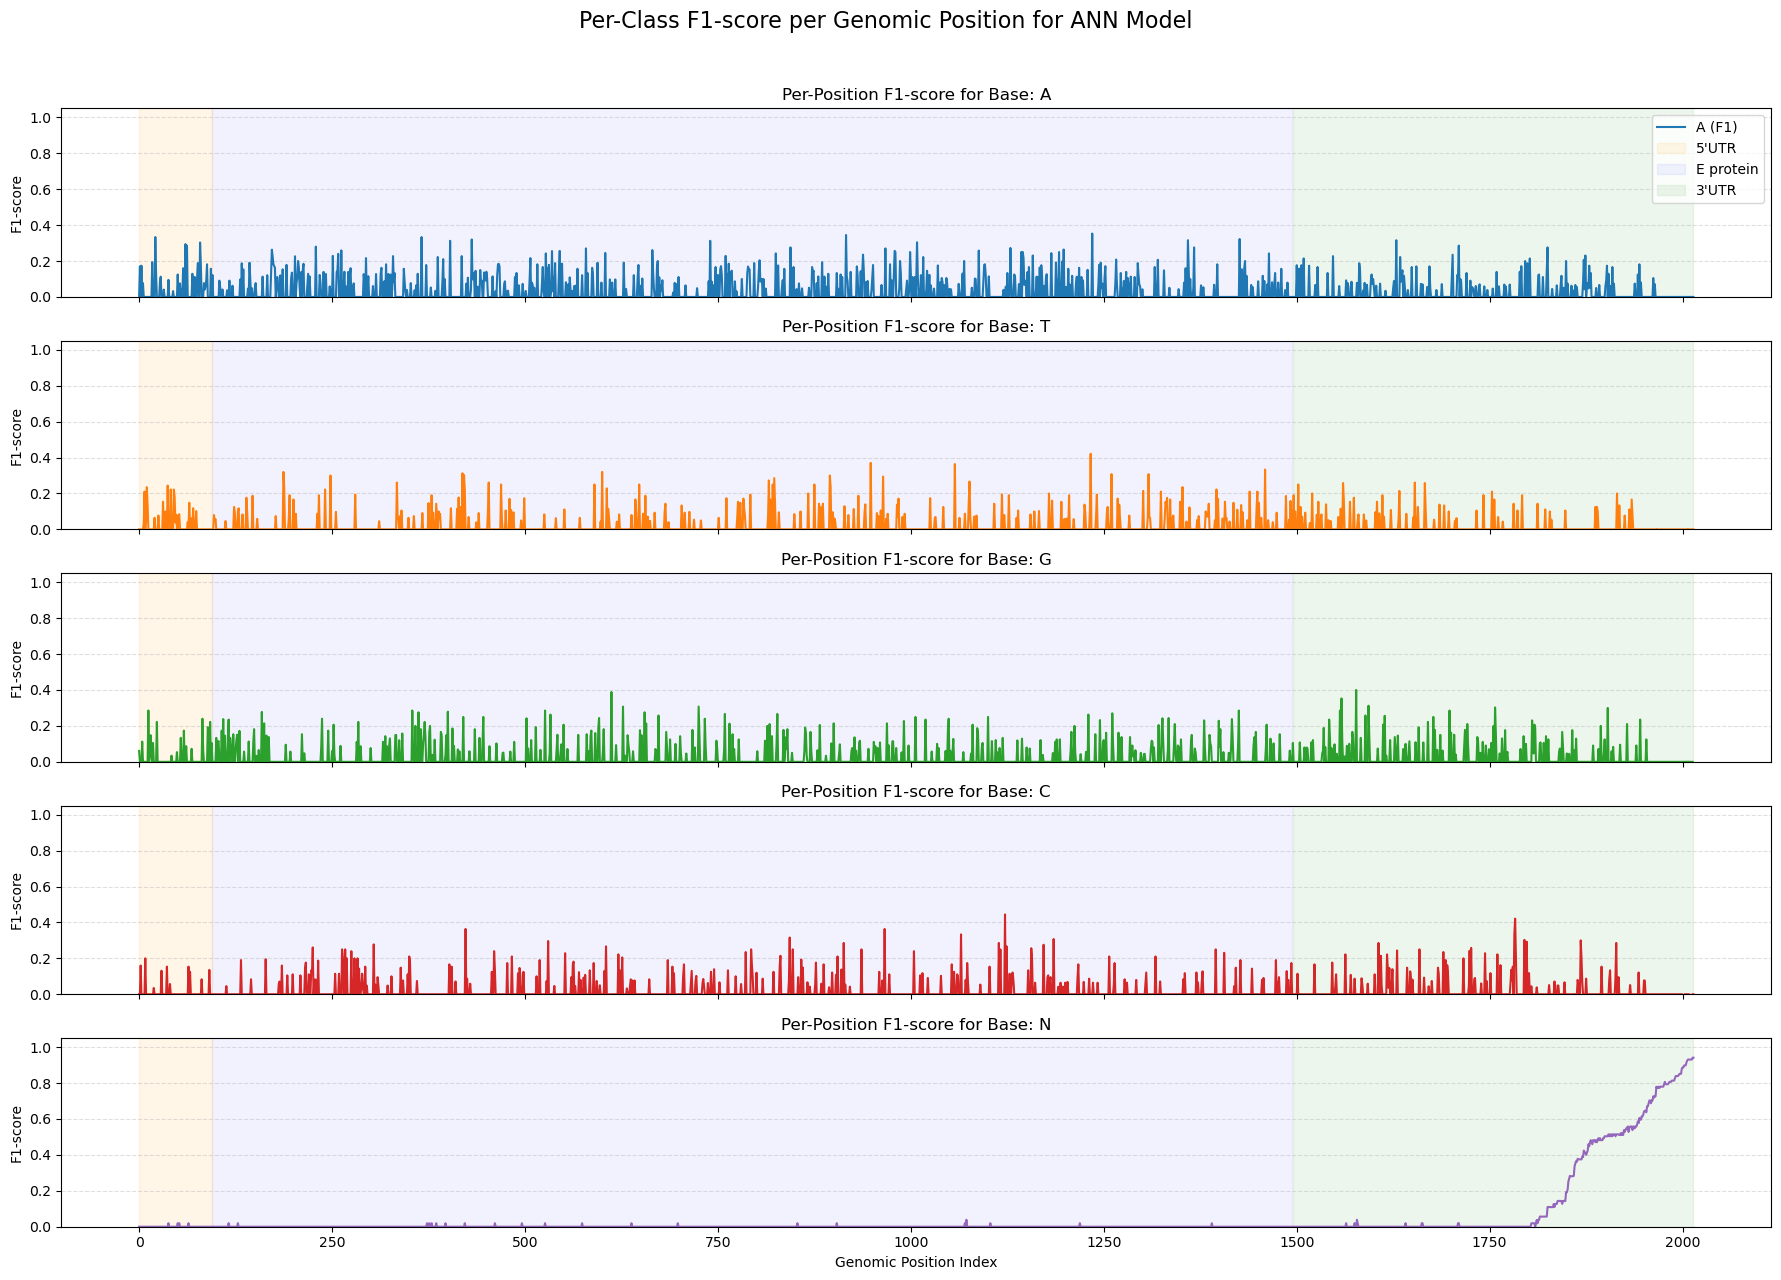

In [23]:
class_labels = {
    '1': 'A',
    '2': 'T',
    '3': 'G',
    '4': 'C',
    '0': 'N'
}
class_keys = ['1','2','3','4','0']
f1_matrix = report_df[[f'f1_{key}' for key in class_keys]].values

n_classes = len(class_keys)
fig, axes = plt.subplots(n_classes, 1, figsize=(18, 2.5 * n_classes), sharex=True, sharey=True)

for idx, key in enumerate(class_keys):
    ax = axes[idx]
    ax.plot(range(len(report_df)), f1_matrix[:, idx], label=f"{class_labels[key]} (F1)", color='C'+str(idx))
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Position F1-score for Base: {class_labels[key]}")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Highlight regions (only label once in legend)
    ax.axvspan(utr5_start, utr5_end, color='orange', alpha=0.09, label="5'UTR" if idx==0 else None)
    ax.axvspan(e_start, e_end, color='blue', alpha=0.05, label="E protein" if idx==0 else None)
    ax.axvspan(utr3_start, utr3_end, color='green', alpha=0.07, label="3'UTR" if idx==0 else None)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Genomic Position Index")
plt.suptitle("Per-Class F1-score per Genomic Position for ANN Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Per-Class F1-score per Genomic Position for ANN Model

The above figure presents the per-position F1-score for each nucleotide base (A, T, G, C, N) across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome, as predicted by the Artificial Neural Network (ANN) model. Each subplot corresponds to a different base, with colored backgrounds highlighting the biologically distinct regions of the genome.

#### Key Insights:

- **Uniformly low F1-scores for major bases:**  
  The F1-scores for the primary nucleotide bases (A, T, G, C) remain consistently low across nearly all genomic positions, rarely exceeding 0.4 and often clustering near zero. This indicates the ANN’s limited capacity to correctly classify individual bases at specific positions, further reinforcing its difficulty in capturing the nuanced patterns required for accurate nucleotide prediction from environmental features alone.

- **Base-specific variability:**  
  While all four major bases exhibit generally poor F1-scores, occasional isolated spikes are observed at a handful of positions. These do not appear to be region-specific and likely reflect chance correct predictions in positions with lower sequence variability.

- **N base artifact:**  
  The F1-score for the 'N' base (padding/unknown) remains at zero throughout most of the sequence, but rises sharply toward the terminal end of the 3′UTR. This mirrors the pattern seen in other performance metrics and results from technical padding during sequence normalization rather than true model learning.

- **Biological and technical interpretation:**  
  The consistently poor F1-scores for all nucleotide classes across the functionally relevant regions (5′UTR and E protein) indicate that environmental inputs alone are insufficient for reliable, position-specific nucleotide classification by an MLP. The observed artifacts at the sequence ends highlight the importance of careful interpretation of model performance in regions affected by technical preprocessing steps.

- **Comparative perspective:**  
  The pattern observed here closely parallels the trends seen in macro F1-score and accuracy plots, further emphasizing the inherent challenge of the forecasting task with the current feature set and model architecture.

#### Heatmap for Confusion Matrix¶

In [25]:
# Merge to associate macro_f1 with each confusion matrix
merged_df = pd.merge(report_df[['position', 'macro_f1']], conf_matrix_df, on='position')

base_labels = ['N', 'A', 'T', 'G', 'C']

def plot_conf_matrices_grid(df, positions, base_labels, fig_title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for idx, pos in enumerate(positions):
        cm = np.array(df[df['position'] == pos]['confusion_matrix'].values[0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=base_labels, yticklabels=base_labels, 
                    ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{pos}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    # Hide any unused subplots (if less than 10)
    for i in range(len(positions), 10):
        axes[i].axis('off')
    plt.suptitle(fig_title, fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

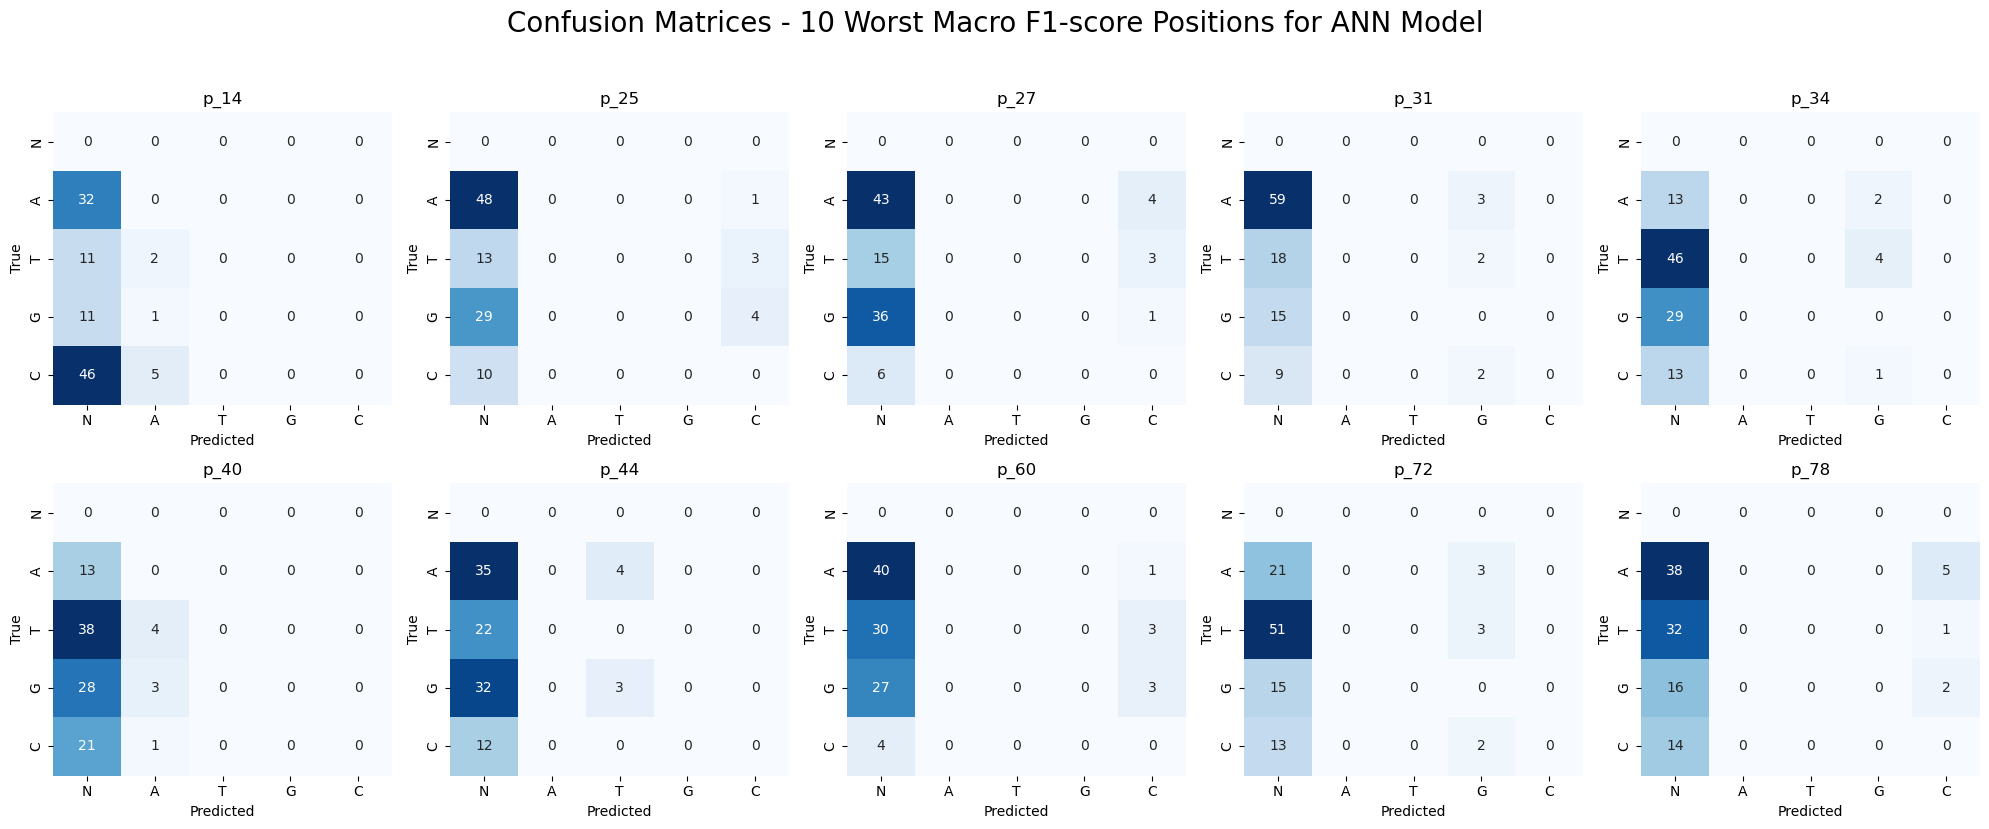

In [26]:
# 10 worst F1-score positions
worst_10 = merged_df.nsmallest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, worst_10, base_labels, "Confusion Matrices - 10 Worst Macro F1-score Positions for ANN Model")

### Analysis of Confusion Matrices — 10 Worst Macro F1-score Positions for ANN Model

The above figure displays the confusion matrices for the 10 nucleotide positions with the lowest macro F1-scores in the Artificial Neural Network (ANN) model. Each matrix summarizes the frequency of true versus predicted nucleotide classes at a single genomic position, highlighting model performance for the most challenging sites across the test set. Rows correspond to the true base, columns to the predicted base (N, A, T, G, C).

#### Key Insights:

- **Severe class confusion:**  
  At all displayed positions, the model overwhelmingly predicts the 'N' (padding/unknown) class, regardless of the true nucleotide base. Very few predictions are assigned to any of the true nucleotide classes (A, T, G, C), resulting in sparse or nearly empty off-diagonal cells except in the 'N' column.

- **Systematic misclassification:**  
  The confusion matrices reveal a pattern of systematic misclassification, where the majority of true bases—whether A, T, G, or C—are incorrectly classified as 'N'. This indicates a strong prediction bias or collapse in the model, failing to differentiate between genuine nucleotides and padding even in non-terminal genomic regions.

- **Minimal correct predictions:**  
  Correct predictions for the actual base (main diagonal) are exceedingly rare or completely absent at these positions. Occasional non-'N' predictions are observed but do not align with the true class, highlighting the model’s inability to distinguish nucleotide identities at the worst-performing sites.

- **Implication for model reliability:**  
  These results confirm that, at the most difficult positions, the ANN’s output is dominated by non-informative, default predictions. This failure is likely due to a combination of low feature informativeness and possible class imbalance at these positions, where environmental inputs alone provide insufficient context for accurate nucleotide forecasting.

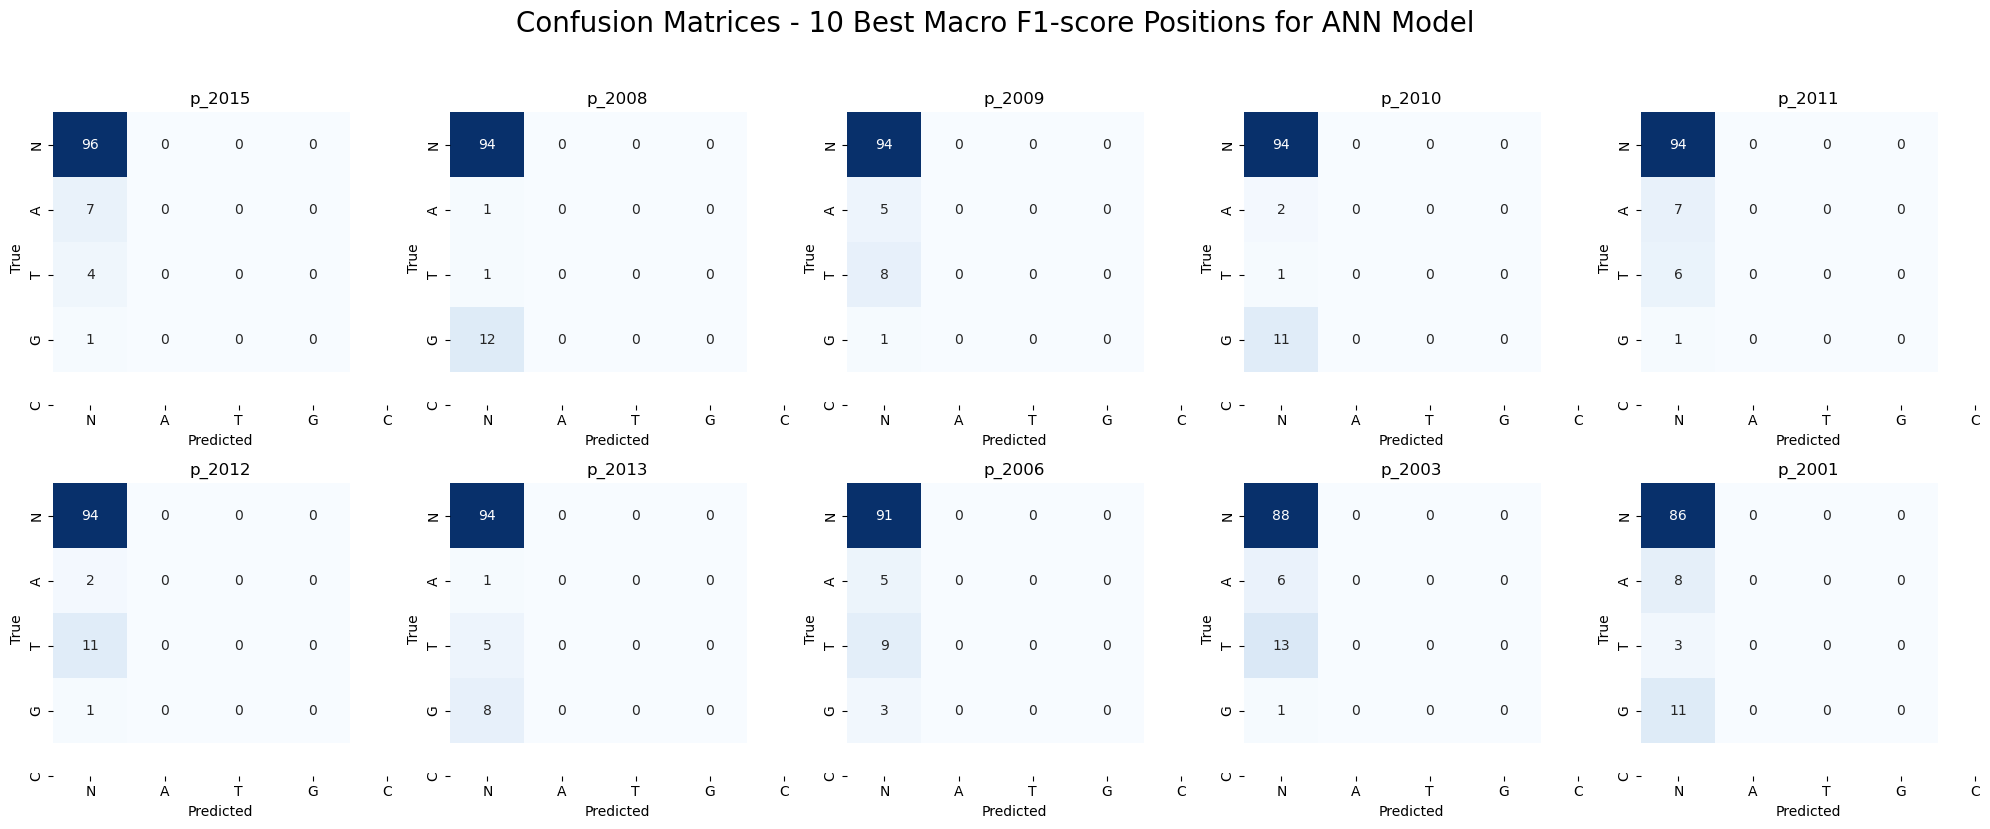

In [27]:
# 10 best F1-score positions
best_10 = merged_df.nlargest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, best_10, base_labels, "Confusion Matrices - 10 Best Macro F1-score Positions for ANN Model")

### Analysis of Confusion Matrices — 10 Best Macro F1-score Positions for ANN Model

The above figure shows the confusion matrices for the 10 nucleotide positions with the highest macro F1-scores in the Artificial Neural Network (ANN) model. Each matrix summarizes the classification performance for a single genomic position, with rows representing the true base and columns the predicted base (N, A, T, G, C).

#### Key Insights:

- **Dominance of the 'N' class:**  
  At all of the best-performing positions, the overwhelming majority of true and predicted values are for the 'N' (padding/unknown) class. The matrices are nearly empty aside from the top-left cell, indicating that the model is almost exclusively predicting 'N' at these positions.

- **Trivial prediction task:**  
  The high macro F1-scores at these positions are not the result of improved biological learning, but rather reflect the abundance of 'N' bases due to padding at the ends of sequences. As such, the ANN's accurate predictions are simply reproducing this technical artifact rather than capturing genuine nucleotide identity.

- **Limited biological informativeness:**  
  Very few, if any, predictions are made for actual nucleotides (A, T, G, C), as seen in the near-zero counts across the rest of each confusion matrix. This confirms that the apparent high performance at these positions does not translate into improved predictive capacity for the biologically relevant nucleotide classes.

- **Implication for model assessment:**  
  These results highlight the importance of contextualizing model performance, especially in regions heavily affected by technical preprocessing (sequence padding). While the model achieves near-perfect scores at these positions, it does so by exploiting dataset artifacts rather than underlying biological patterns.

- **Consistency with prior analyses:**  
  The findings here are consistent with the trends observed in per-position accuracy and macro F1-score plots, emphasizing that genuine predictive challenges remain unmet across the functionally significant regions of the genome.

In [28]:
# Save to CSV (or JSON for confusion matrices)
report_df.to_csv('../results/ann_per_position_classification_report.csv', index=False)
conf_matrix_df.to_json('../results/ann_per_position_confusion_matrices.json', orient='records')

### Save the model

In [29]:
joblib.dump(model, '../models/ann_mlp_model.joblib')

['../models/ann_mlp_model.joblib']